# Exploratory Data Analysis (EDA) - PhoNER COVID-19 Dataset

This notebook performs a comprehensive Exploratory Data Analysis on the **PhoNER_COVID19** dataset for Vietnamese Named Entity Recognition (NER).

## Objectives:
1. Parse the CoNLL training, validation, and test datasets.
2. Calculate and compare dataset sizes (number of sentences, total tokens).
3. Analyze sentence length distributions.
4. Track and visualize entity label distributions (e.g., `ORGANIZATION`, `LOCATION`, `SYMPTOM_AND_DISEASE`, etc.).
5. Draw design recommendations for the downstream NER modeling pipeline.

In [26]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
# Set elegant styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

## 1. Define Parser and Paths

In [27]:
DATA_DIR = "../DATA"
TRAIN_PATH = os.path.join(DATA_DIR, "train_word.conll")
DEV_PATH = os.path.join(DATA_DIR, "dev_word.conll")
TEST_PATH = os.path.join(DATA_DIR, "test_word.conll")

def parse_conll(file_path):
    """
    Read CoNLL file and extract sentences. Each sentence is a list of (word, tag) tuples.
    """
    sentences = []
    current_sentence = []
    
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
                continue
            parts = line.split()
            if len(parts) >= 2:
                word = parts[0]
                tag = parts[-1]
                current_sentence.append((word, tag))
                
        if current_sentence:
            sentences.append(current_sentence)
            
    return sentences

## 2. Load and Compute Basic Statistics

In [28]:
train_sents = parse_conll(TRAIN_PATH)
dev_sents = parse_conll(DEV_PATH)
test_sents = parse_conll(TEST_PATH)

stats = []
for name, sents in [("Train", train_sents), ("Validation", dev_sents), ("Test", test_sents)]:
    num_sents = len(sents)
    lengths = [len(s) for s in sents]
    total_tokens = sum(lengths)
    mean_len = np.mean(lengths)
    median_len = np.median(lengths)
    max_len = np.max(lengths)
    min_len = np.min(lengths)
    
    stats.append({
        "Split": name,
        "Sentences": num_sents,
        "Total Tokens": total_tokens,
        "Min Length": min_len,
        "Max Length": max_len,
        "Mean Length": round(mean_len, 2),
        "Median Length": int(median_len)
    })

df_stats = pd.DataFrame(stats)
df_stats

,Split,Sentences,Total Tokens,Min Length,Max Length,Mean Length,Median Length
0,Train,5027,132510,6,161,26.36,24
1,Validation,2000,56283,7,138,28.14,25
2,Test,3000,85678,7,162,28.56,26


## 3. Visualize Sentence Length Distributions

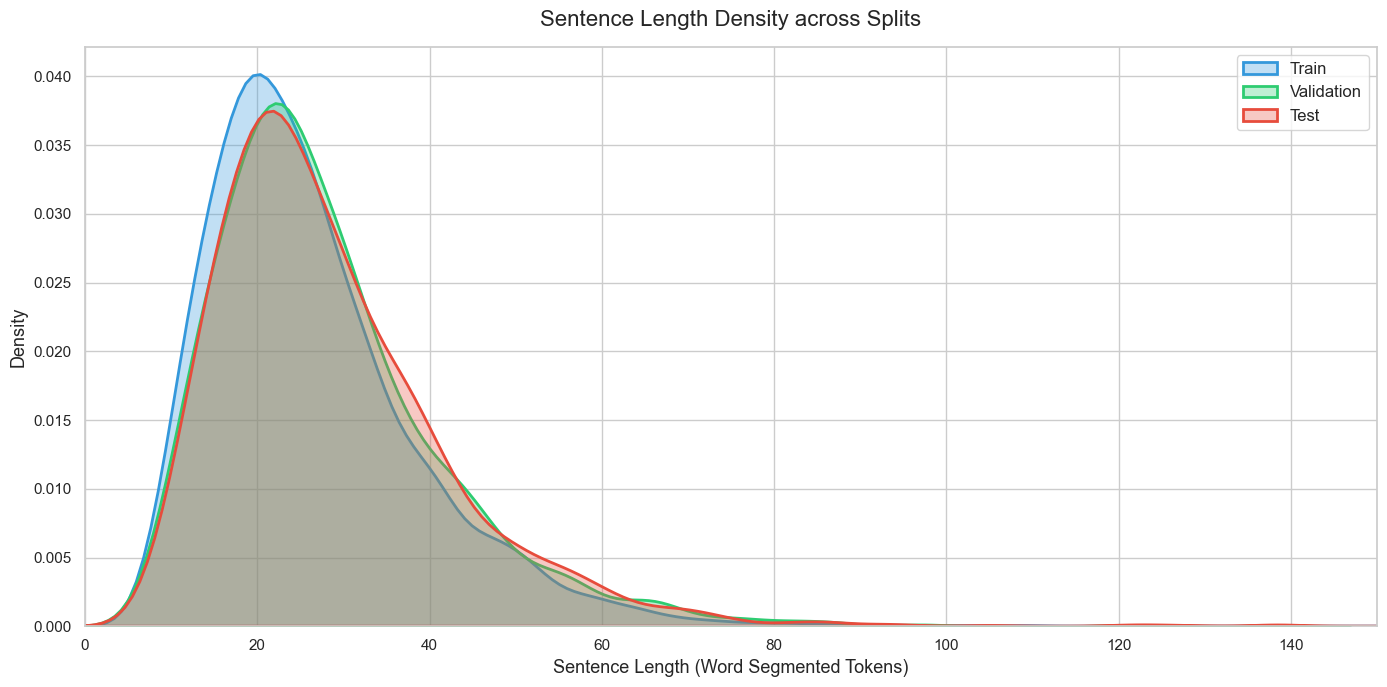

In [29]:
plt.figure(figsize=(14, 7))
colors = ["#3498db", "#2ecc71", "#e74c3c"]

for i, (name, sents) in enumerate([("Train", train_sents), ("Validation", dev_sents), ("Test", test_sents)]):
    lengths = [len(s) for s in sents]
    sns.kdeplot(lengths, fill=True, label=name, color=colors[i], alpha=0.3, linewidth=2)

plt.title("Sentence Length Density across Splits", fontsize=16, pad=15)
plt.xlabel("Sentence Length (Word Segmented Tokens)", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.xlim(0, 150)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 4. Entity Label Distribution Analysis

Let's count how many times each type of entity appears in the dataset splits.

In [30]:
def count_entities(sentences):
    """
    Count only B- tags to get the true count of entity occurrences.
    """
    entities = []
    for sent in sentences:
        for word, tag in sent:
            if tag.startswith("B-"):
                entities.append(tag[2:])  # Extract class name (e.g. LOCATION)
    return Counter(entities)

train_entities = count_entities(train_sents)
dev_entities = count_entities(dev_sents)
test_entities = count_entities(test_sents)

df_entities = pd.DataFrame({
    "Train": pd.Series(train_entities),
    "Validation": pd.Series(dev_entities),
    "Test": pd.Series(test_entities)
}).fillna(0).astype(int)

df_entities["Total"] = df_entities.sum(axis=1)
df_entities = df_entities.sort_values(by="Total", ascending=False)
df_entities

,Train,Validation,Test,Total
LOCATION,5398,2737,4441,12576
PATIENT_ID,3240,1276,2005,6521
DATE,2549,1103,1654,5306
SYMPTOM_AND_DISEASE,1439,766,1136,3341
ORGANIZATION,1137,551,771,2459
AGE,682,361,582,1625
GENDER,542,277,462,1281
NAME,349,188,318,855
JOB,205,132,173,510
TRANSPORTATION,226,87,193,506


## 5. Visualise Entity Label Frequency

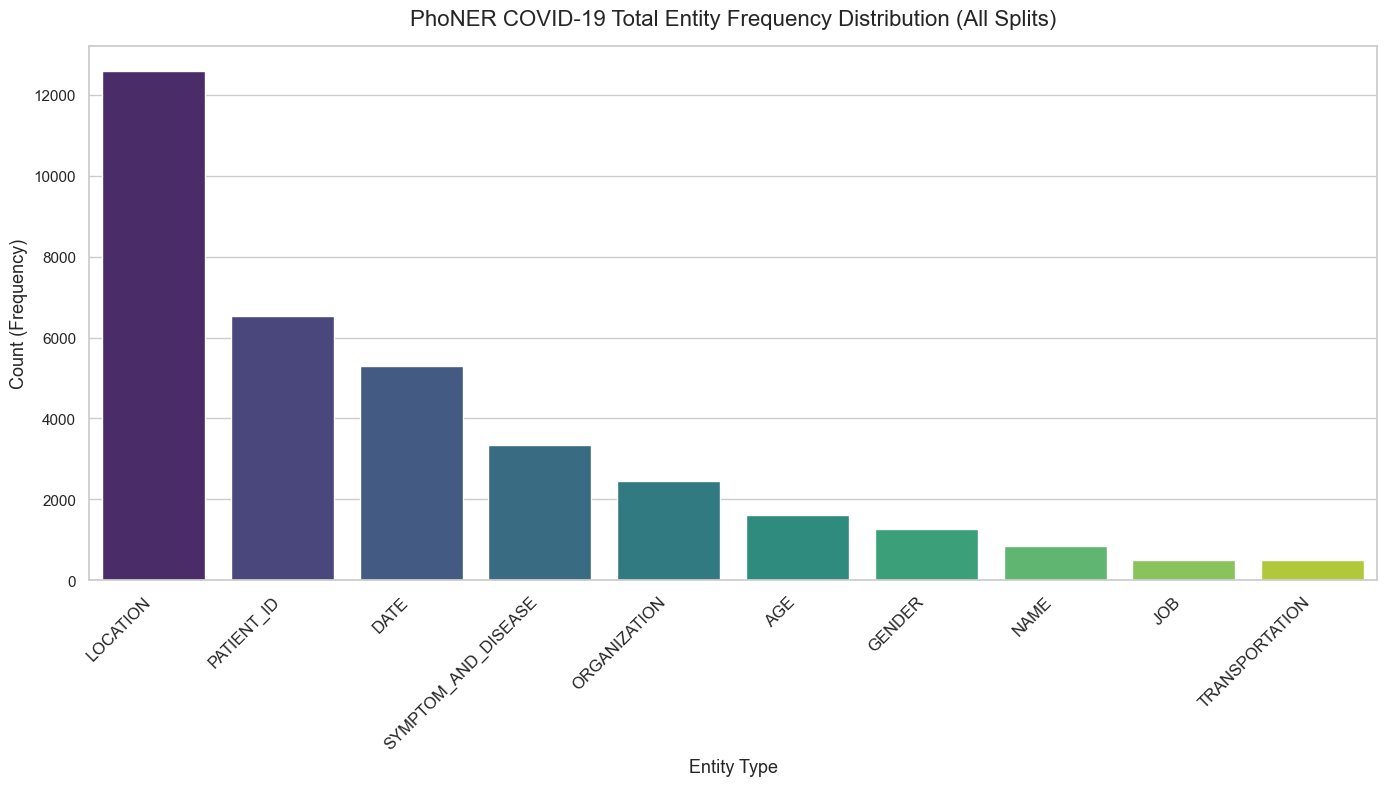

In [31]:
plt.figure(figsize=(14, 8))
palette = sns.color_palette("viridis", len(df_entities))

sns.barplot(
    x=df_entities.index,
    y=df_entities["Total"],
    palette=palette
)

plt.title("PhoNER COVID-19 Total Entity Frequency Distribution (All Splits)", fontsize=16, pad=15)
plt.xlabel("Entity Type", fontsize=13)
plt.ylabel("Count (Frequency)", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.tight_layout()
plt.show()

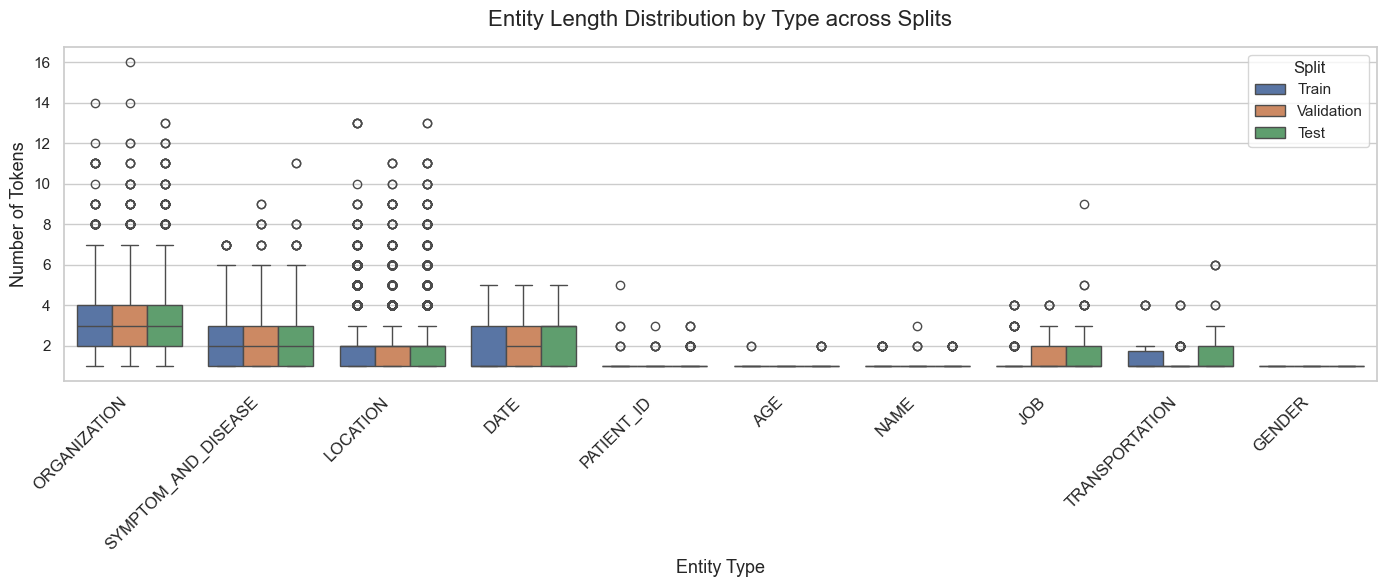

                       count      mean       std  min  25%  50%   75%   max
Type                                                                       
AGE                   1625.0  1.004923  0.070013  1.0  1.0  1.0  1.00   2.0
DATE                  5306.0  2.011685  1.019441  1.0  1.0  2.0  3.00   5.0
GENDER                1281.0  1.000000  0.000000  1.0  1.0  1.0  1.00   1.0
JOB                    510.0  1.441176  0.872788  1.0  1.0  1.0  2.00   9.0
LOCATION             12576.0  2.045881  1.343463  1.0  1.0  2.0  2.00  13.0
NAME                   855.0  1.036257  0.193198  1.0  1.0  1.0  1.00   3.0
ORGANIZATION          2459.0  3.445710  1.948639  1.0  2.0  3.0  4.00  16.0
PATIENT_ID            6521.0  1.006901  0.102641  1.0  1.0  1.0  1.00   5.0
SYMPTOM_AND_DISEASE   3341.0  2.204729  1.214923  1.0  1.0  2.0  3.00  11.0
TRANSPORTATION         506.0  1.318182  0.680380  1.0  1.0  1.0  1.75   6.0


In [32]:
def extract_full_entities(sentences):
    """
    Trích xuất toàn bộ thực thể (bao gồm cả B- và các thẻ I- đi kèm)
    để tính toán độ dài trung bình của các loại thực thể.
    """
    entities = []
    for sent in sentences:
        current_entity = []
        current_type = None
        for word, tag in sent:
            if tag.startswith("B-"):
                if current_entity:
                    entities.append(
                        (current_type, " ".join(current_entity), len(current_entity))
                    )
                current_type = tag[2:]
                current_entity = [word]
            elif tag.startswith("I-") and current_type == tag[2:]:
                current_entity.append(word)
            else:
                if current_entity:
                    entities.append(
                        (current_type, " ".join(current_entity), len(current_entity))
                    )
                    current_entity = []
                    current_type = None
        if current_entity:
            entities.append(
                (current_type, " ".join(current_entity), len(current_entity))
            )
    return entities


# Gom dữ liệu từ 3 tập
splits_data = {"Train": train_sents, "Validation": dev_sents, "Test": test_sents}
all_entities = []

for split_name, sents in splits_data.items():
    ents = extract_full_entities(sents)
    for t, w, l in ents:
        all_entities.append({"Split": split_name, "Type": t, "Phrase": w, "Length": l})

df_ents = pd.DataFrame(all_entities)

# Trực quan hóa phân bố độ dài thực thể
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_ents, x="Type", y="Length", hue="Split")
plt.title("Entity Length Distribution by Type across Splits", fontsize=16, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.ylabel("Number of Tokens", fontsize=13)
plt.xlabel("Entity Type", fontsize=13)
plt.tight_layout()
plt.show()

# Thống kê mô tả về độ dài (ví dụ: Trung bình, độ lệch chuẩn, lớn nhất)
print(df_ents.groupby("Type")["Length"].describe())

1. **Imbalanced Classes**: `LOCATION`, `PATIENT_ID`, `DATE`, and `PATIENT_ID` are heavily populated entities, while `TRANSPORTATION`, `JOB`, and `NAME` are very sparse. We should consider weighted loss coefficients or oversampling during training if models struggle on sparse classes.
2. **Sentence Length Constraints**: The median sentence length is ~25 tokens, with 99% of sentences falling below 120 tokens. A sequence length configuration of `MAX_SEQ_LENGTH = 128` or `256` represents an excellent trade-off between complete context and training execution speeds.
